#   LangGraph 활용 - Corrective RAG (CRAG)

---

## 1. 환경 설정

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
import warnings
import logging
from datetime import datetime
import operator
from typing import TypedDict, Union, List, Dict, Tuple, Any, Annotated
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# 경고 무시 설정
warnings.filterwarnings("ignore")

# 로깅 설정
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

## 2. Corrective RAG (CRAG) 구현
- CRAG (Corrective Retrieval-Augmented Generation) 
- 논문: https://arxiv.org/pdf/2401.15884

- 주요 과정: 검색 -> 평가 -> 지식 정제 또는 웹 검색 -> 답변 생성

   1. 문서 관련성 평가 (`grade_documents`):
      - 각 문서의 관련성을 평가
      - 기준을 통과하는 문서만을 유지

   1. 지식 정제 (`refine_knowledge`):
      - 문서를 "지식 조각"으로 분할하고 각각의 관련성을 평가
      - 관련성 높은(0.5 초과) 지식 조각만 유지

   1. 웹 검색 (`web_search`):
      - 문서가 충분한 정보를 담지 못한 경우 외부 지식을 활용
      - 웹 검색 결과를 기존 문서에 추가 

   1. 답변 생성 (`generate_answer`):
      - 정제된 지식 조각을 사용하여 답변을 생성
      - 관련 정보가 없을 경우 적절한 메시지를 반환



###  2-1. Tool 정의

`(1) 벡터저장소 검색기`

In [3]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

class AdaptiveVectorStore:
    """적응형 검색을 위한 벡터 저장소"""
    
    def __init__(self, collection_name: str, persist_dir: str = "./chroma_db"):
        # 임베딩 모델 사용 
        self.embeddings = OpenAIEmbeddings(
            model="text-embedding-3-small",
        )
        
        # Chroma DB 초기화
        self.vector_db = Chroma(
            embedding_function=self.embeddings,
            collection_name=collection_name,
            persist_directory=persist_dir,
        )
        
        # 다단계 검색 전략
        self.search_configs = {
            "initial": {"k": 3, "score_threshold": 0.3},
            "expanded": {"k": 5, "score_threshold": 0.1},
            "exhaustive": {"k": 10, "score_threshold": 0.0}
        }

        logger.info(f"✅ Vector store '{collection_name}' initialized")

    def multi_stage_search(self, query: str):
        """단계별 검색 전략"""
        # 1차: 정밀 검색
        initial = self.vector_db.as_retriever(
            search_type="similarity_score_threshold",
            search_kwargs=self.search_configs["initial"]
        ).invoke(query)

        logger.info(f"🔍 1차 검색 모드: {len(initial)}개의 문서 검색")

        if len(initial) < 1:
            # 2차: 확장 검색
            expanded = self.vector_db.as_retriever(
                search_type="similarity_score_threshold",
                search_kwargs=self.search_configs["expanded"]
            ).invoke(query)

            logger.info(f"🔍 2차 검색 모드: {len(expanded)}개의 문서 검색")

            if len(expanded) < 1:
                # 3차: 포괄 검색
                exhaustive = self.vector_db.as_retriever(
                    search_type="similarity_score_threshold",
                    search_kwargs=self.search_configs["exhaustive"]
                ).invoke(query)

                logger.info(f"🔍 3차 검색 모드: {len(exhaustive)}개의 문서 검색")

                return exhaustive
            
            return expanded
        else:
            return initial


# 사용 예시
vector_db = AdaptiveVectorStore(collection_name="restaurant_menu")
results = vector_db.multi_stage_search("채식주의자를 위한 메뉴가 있나요?")

2025-11-06 19:41:57,047 - chromadb.telemetry.product.posthog - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
2025-11-06 19:41:59,231 - __main__ - INFO - ✅ Vector store 'restaurant_menu' initialized
2025-11-06 19:42:00,761 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:00,848 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.3
2025-11-06 19:42:00,849 - __main__ - INFO - 🔍 1차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:01,817 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:01,820 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.1
2025-11-06 19:42:01,821 - __main__ - INFO - 🔍 2차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:03,032 - httpx - INFO - HTTP Request: POST https://api.openai.c

In [4]:
for result in results:
    print(result)

`(2) 웹 검색`

In [5]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(max_results=5)

search_tool.invoke("스테이크와 어울리는 와인")

{'query': '스테이크와 어울리는 와인',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://alcohol.hobby-tech.com/entry/%EC%8A%A4%ED%85%8C%EC%9D%B4%ED%81%AC%EC%99%80-%EC%B0%B0%EB%96%A1%EA%B6%81%ED%95%A9-%EC%8A%A4%ED%85%8C%EC%9D%B4%ED%81%AC%EC%97%90-%EC%96%B4%EC%9A%B8%EB%A6%AC%EB%8A%94-%EC%99%80%EC%9D%B8-5%EA%B0%80%EC%A7%80',
   'title': '스테이크와 찰떡궁합! 스테이크에 어울리는 와인 5가지 - 술',
   'content': '카베르네 소비뇽 (Cabernet Sauvignon) – 스테이크 와인의 대표주자 **어울리는 스테이크:** * 리브아이 스테이크 * 티본 스테이크 **추천 와인:** 카베르네 소비뇽은 특히 **마블링이 많은 소고기 스테이크**와 환상적인 조화를 이룹니다. **어울리는 스테이크:** * 바비큐 스테이크 * 페퍼크러스트 스테이크 **추천 와인:** **어울리는 스테이크:** * 안심 스테이크 (필레 미뇽) * 티본 스테이크 특히 **부드러운 안심 스테이크와 함께 즐기면 와인의 깊은 과일향과 육즙이 환상적인 조화를 이룹니다.** **어울리는 스테이크:** * 등심 스테이크 * 미디엄 레어 스테이크 **어울리는 스테이크:** * 바비큐 스타일 스테이크 | 와인 종류 | 특징 | 어울리는 스테이크 | | 카베르네 소비뇽 | 강한 탄닌, 풀바디 | 마블링이 많은 스테이크 | | 시라/쉬라즈 | 스파이시하고 진한 맛 | 숯불에 구운 스테이크 | | 진판델 | 달콤한 향과 강한 바디감 | 바비큐 소스 스테이크 |',
   'score': 0.9368016,
   'raw_content': None},
  {'url': 'https://m

### 2-2. LLM 모델

`(1) Retrieval Grader`

In [6]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 문서 관련성 평가 결과를 위한 데이터 모델 정의
class GradeDocuments(BaseModel):
    """Three-class score for relevance check on retrieved documents."""
    relevance_score: Literal["correct", "incorrect", "ambiguous"] = Field(
        description="Document relevance to the question: 'correct', 'incorrect', or 'ambiguous'"
    )

# LLM 모델 초기화 및 구조화된 출력 설정
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 문서 관련성 평가를 위한 시스템 프롬프트 정의
system_prompt = """
You are an expert evaluator tasked with assessing the relevance of retrieved documents to a user's question. Your role is crucial in enhancing the quality of information retrieval systems.

[평가 기준]
1. 키워드 관련성: 문서가 질문의 주요 단어나 유사어를 포함하는지 확인
2. 의미적 관련성: 문서의 전반적인 주제가 질문의 의도와 일치하는지 평가
3. 부분 관련성: 질문의 일부를 다루거나 맥락 정보를 제공하는 문서도 고려
4. 답변 가능성: 직접적인 답이 아니더라도 답변 형성에 도움될 정보 포함 여부 평가

[점수 체계]
- 'correct': 문서가 명확히 관련 있고, 질문에 답하는 데 필요한 정보를 포함함.
- 'incorrect': 문서가 명확히 무관하거나, 질문에 도움이 되지 않는 정보를 포함함.
- 'ambiguous': 문서의 관련성이 불분명하거나, 일부 관련 정보는 있지만 유용성이 확실하지 않음, 혹은 질문과 약간만 관련 있음.

[주의사항]
- 단순 단어 매칭이 아닌 질문의 전체 맥락을 고려하세요
- 완벽한 답변이 아니어도 유용한 정보가 있다면 관련 있다고 판단하세요

Your evaluation plays a critical role in improving the overall performance of the information retrieval system. Strive for balanced and thoughtful assessments.
"""

# 채점 프롬프트 템플릿 생성
grade_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "Document: \n\n {document} \n\n Question: {question}"),
])

# Retrieval Grader 파이프라인 구성
retrieval_grader = grade_prompt | structured_llm_grader
    
# 관련성 평가 실행
question = "채식주의자를 위한 메뉴가 있나요?"
retrieved_docs = vector_db.multi_stage_search(question)
print(f"검색된 문서 수: {len(retrieved_docs)}")

for test_chunk in retrieved_docs:
    print("문서:", test_chunk.page_content)

    relevance = retrieval_grader.invoke({"question": question, "document": test_chunk.page_content})
    print(f"문서 관련성: {relevance.relevance_score}")
    print("=====================================")

2025-11-06 19:42:06,523 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:06,527 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.3
2025-11-06 19:42:06,527 - __main__ - INFO - 🔍 1차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:07,434 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:07,437 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.1
2025-11-06 19:42:07,437 - __main__ - INFO - 🔍 2차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:07,759 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:07,762 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.0
2025-11-06 19:42:07,762 - __main__ - INFO - 🔍 3차 검색 모드: 0개의 문서 검색


검색된 문서 수: 0


In [7]:
question = "해산물 요리를 추천해주세요."
retrieved_docs = vector_db.multi_stage_search(question)
print(f"검색된 문서 수: {len(retrieved_docs)}")

for test_chunk in retrieved_docs:
    print("문서:", test_chunk.page_content)

    relevance = retrieval_grader.invoke({"question": question, "document": test_chunk.page_content})
    print(f"문서 관련성: {relevance.relevance_score}")
    print("=====================================")

2025-11-06 19:42:08,061 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:08,064 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.3
2025-11-06 19:42:08,065 - __main__ - INFO - 🔍 1차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:08,530 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:08,532 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.1
2025-11-06 19:42:08,533 - __main__ - INFO - 🔍 2차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:08,809 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:08,812 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.0
2025-11-06 19:42:08,812 - __main__ - INFO - 🔍 3차 검색 모드: 0개의 문서 검색


검색된 문서 수: 0


---
### **[실습]**

- Retrieval Grader를 재구성하고, 샘플 데이터에 대한 테스트를 수행합니다. 

In [8]:
# 여기에 코드를 작성하세요.

`(2) Answer Generator`

In [9]:
def generator_answer(question, docs):
    template = """당신은 정확하고 도움되는 답변을 제공하는 AI 어시스턴트입니다.
    
        [지침]
        1. 제공된 문맥만을 사용하여 답변
        2. 불확실한 경우 명확히 표시
        3. 간결하되 완전한 답변 제공

        [문맥]
        {context}

        [질문]
        {question}

        [답변]"""

    prompt = ChatPromptTemplate.from_template(template)
    llm = ChatOpenAI(model='gpt-4.1-mini', temperature=0)    

    def format_docs(docs):
        return "\n\n".join([d.page_content for d in docs])
    
    rag_chain = prompt | llm | StrOutputParser()
    
    generation = rag_chain.invoke({"context": format_docs(docs), "question": question})

    return generation


# 검색된 문서를 기반으로 질문에 대한 답변 생성
generation = generator_answer(question, docs=retrieved_docs)
print(generation)

2025-11-06 19:42:10,076 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


제공된 문맥에 해산물 요리에 대한 정보가 없어 추천이 어렵습니다.


---
### **[실습]**

- Answer Generator를 재구성하고, 샘플 데이터에 대한 테스트를 수행합니다. 

In [10]:
# 여기에 코드를 작성하세요.

`(3) Question Re-writer`

In [11]:
def rewrite_question(question: str) -> str:
    """
    주어진 질문을 벡터 저장소 검색에 최적화된 형태로 다시 작성합니다.
    """
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

    system_prompt = """당신은 검색 최적화 전문가입니다.

    질문 개선 전략:
    1. 핵심 키워드 추출 및 강조
    2. 모호한 대명사를 구체적 용어로 대체
    3. 동의어 및 관련 용어 추가
    4. 시간적/공간적 맥락 명확화
    5. 복합 질문을 단순 질문으로 분해

    예시:
    - 원본: "그거 얼마야?"
    - 개선: "스테이크 메뉴 가격 정보"
    
    - 원본: "여기서 뭐가 제일 맛있어?"
    - 개선: "레스토랑 인기 메뉴 추천 시그니처 요리"

    주의사항:
    - 원래 의도 유지
    - 과도한 확장 지양
    - 검색 친화적 표현 사용"""

    re_write_prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", """[원본 질문]
{question}

검색에 최적화된 질문으로 재작성하세요. 
간결하고 명확하게, 핵심 키워드를 포함하여."""),
    ])

    question_rewriter = re_write_prompt | llm | StrOutputParser()
    rewritten_question = question_rewriter.invoke({"question": question})

    return rewritten_question

# 질문 다시 쓰기 테스트
rewritten_question = rewrite_question(question)
print(f"원본 질문: {question}")
print(f"다시 쓴 질문: {rewritten_question}")

2025-11-06 19:42:10,666 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


원본 질문: 해산물 요리를 추천해주세요.
다시 쓴 질문: 해산물 요리 추천 인기 메뉴 베스트


---
### **[실습]**

- Question Rewiriter를 재구성하고, 샘플 데이터에 대한 테스트를 수행합니다. 

In [12]:
# 여기에 코드를 작성하세요.

`(4) Knowledge Refiner`

In [13]:
class RefinedKnowledge(BaseModel):
    """
    문서에서 추출된 정제된 지식 조각을 나타냅니다.
    """
    knowledge_strip: str = Field(description="문서에서 추출된 정제된 지식 조각")
    binary_score: str = Field(
        description="문서가 질문과 관련이 있는지 여부, 'yes' 또는 'no'"
    )

structured_llm_refiner = llm.with_structured_output(RefinedKnowledge)

# 지식 정제를 위한 프롬프트
refine_system_prompt = """
당신은 지식 정제 전문가입니다. 주어진 질문과 관련하여 문서에서 핵심 정보를 추출하고 관련성을 평가하는 것이 당신의 임무입니다.

[지시사항]
1. 질문과 문서를 주의 깊게 읽으세요.
2. 질문에 답하는 데 관련이 있는 문서의 핵심 정보들을 식별하세요.
3. 각 핵심 정보에 대해:
   a. 간결하게 추출하고 요약하세요 (정보당 1-2문장을 목표로 함).
   b. 질문과의 관련성을 'yes' (관련 있음) 또는 'no' (관련 없음)로 평가하세요.
4. 각 정보를 다음 형식으로 새 줄에 제시하세요:
   [추출된 정보] (yes/no)

[예시 출력]
AI 시스템은 훈련 데이터에 존재하는 편향을 나타낼 수 있습니다. (yes)
의사결정에서 AI 사용은 개인정보 보호 우려를 제기합니다. (yes)
기계학습 모델은 상당한 컴퓨팅 자원을 필요로 합니다. (no)

[참고사항]
사실적이고 객관적인 정보 추출에 집중하세요. 개인적인 의견이나 추측은 피하세요. 3-5개의 핵심 정보 제공을 목표로 하되, 문서에 관련 내용이 특히 풍부한 경우 더 많이 포함해도 됩니다.
"""

refine_prompt = ChatPromptTemplate.from_messages([
    ("system", refine_system_prompt),
    ("human", "[문서]\n{document}\n\n[사용자 질문]\n{question}"),
])

# Knowledge Refiner 파이프라인 구성
knowledge_refiner = refine_prompt | structured_llm_refiner

# 지식 정제 실행
retrieved_docs = vector_db.multi_stage_search(question)
print(f"검색된 문서 수: {len(retrieved_docs)}")

for test_chunk in retrieved_docs:
    print("문서:", test_chunk.page_content)

    refined_knowledge = knowledge_refiner.invoke({"question": question, "document": test_chunk})
    print(f"정제된 지식: {refined_knowledge.knowledge_strip}")
    print(f"정제된 지식 평가: {refined_knowledge.binary_score}")
    print("=====================================")


2025-11-06 19:42:11,447 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:11,450 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.3
2025-11-06 19:42:11,451 - __main__ - INFO - 🔍 1차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:12,326 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:12,329 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.1
2025-11-06 19:42:12,330 - __main__ - INFO - 🔍 2차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:12,612 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:12,615 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.0
2025-11-06 19:42:12,615 - __main__ - INFO - 🔍 3차 검색 모드: 0개의 문서 검색


검색된 문서 수: 0


---
### **[실습]**

- Knowedge Refiner를 재구성하고, 샘플 데이터에 대한 테스트를 수행합니다. 

In [14]:
# 여기에 코드를 작성하세요.

### 3-3. LangGraph로 그래프 구현

`(1) 그래프 State 생성`

In [15]:
from typing import TypedDict, Union, List, Dict, Tuple, Any, Annotated
from langchain_core.documents import Document
import operator

class GraphState(TypedDict):
    """
    Corrective-RAG 그래프 상태
    """
    question: str
    generation: str
    retrieved_documents: List[Tuple[Document, str]]  # 검색 문서 리스트 (문서, 점수) -> 벡터 저장소 검색 결과 (내부지식)
    knowledge_strips: List[Tuple[Document, str]]     # 지식 보강한 결과 리스트 (문서, 점수) -> 최종 생성에 사용되는 문서 (내부지식 + 외부지식)
    num_generations: int
    # Send 결과를 수집하기 위한 필드 - reducer 사용
    graded_documents: Annotated[list, operator.add]   # Map-Reduce에서 평가 결과를 임시로 수집
    refined_knowledge: Annotated[list, operator.add]  # Map-Reduce 패턴에서 병렬 처리 결과를 임시로 수집하는 필드


`(2) Node 구성`

In [16]:
def retrieve(state: GraphState) -> GraphState:
    """문서를 검색하는 함수"""
    logging.info("--- 문서 검색 ---")
    question = state["question"]

    # 문서 검색 로직 (ambiguous 상태로 초기화)
    retrieved_documents = vector_db.multi_stage_search(question)
    retrieved_documents = [(doc, "ambiguous") for doc in retrieved_documents]
    return {"retrieved_documents": retrieved_documents}

def web_search(state: GraphState) -> GraphState:
    """웹 검색을 수행하는 함수"""
    logging.info("--- 웹 검색 ---")
    question = state["question"]
    
    # 웹 검색 로직 (ambiguous 상태로 초기화)
    search_results = search_tool.invoke(question)['results']
    retrieved_documents = [(Document(page_content=str(result)), "ambiguous") 
                          for result in search_results]
    return {"retrieved_documents": retrieved_documents}

In [17]:
# Map 단계: 문서 평가를 위한 Send 생성
def distribute_documents_for_grading(state: GraphState):
    """문서 평가를 위해 각 문서를 개별 노드로 보내는 함수"""
    retrieved_documents = state.get("retrieved_documents", [])
    question = state["question"]
    
    # Send 객체들의 리스트를 반환
    return [
        Send("grade_single_document", {
            "question": question, 
            "document": doc, 
            "grade": grade
        }) 
        for doc, grade in retrieved_documents
    ]

# Send를 위한 개별 문서 평가 함수
def grade_single_document(state: Dict) -> Dict:
    """개별 문서의 관련성을 평가하는 함수 (Send용)"""
    logging.info("--- 개별 문서 관련성 평가 ---")
    question = state["question"]
    document = state["document"]
    
    score = retrieval_grader.invoke({"question": question, "document": document.page_content})
    grade = score.relevance_score.lower()
    
    if grade == "correct":
        logging.info("---문서 관련성: 있음---")
        return {"graded_documents": [(document, "correct")]}
    elif grade == "incorrect":
        logging.info("---문서 관련성: 없음---")
        return {"graded_documents": [(document, "incorrect")]}
    else:
        logging.info("---문서 관련성: 모호함---")
        return {"graded_documents": [(document, "ambiguous")]}

In [18]:
# Map 단계: 지식 정제를 위한 Send 생성
def distribute_documents_for_refining(state: GraphState):
    """지식 정제를 위해 각 문서를 개별 노드로 보내는 함수"""
    graded_documents = state.get("graded_documents", [])
    question = state["question"]
    
    # graded_documents를 평면화
    flattened_docs = []
    for item in graded_documents:
        if isinstance(item, list):
            flattened_docs.extend(item)
        else:
            flattened_docs.append(item)
    
    # Send 객체들의 리스트를 반환
    return [
        Send("refine_single_knowledge", {
            "question": question, 
            "document": doc, 
            "grade": grade
        }) 
        for doc, grade in flattened_docs
    ]

# Send를 위한 개별 지식 정제 함수
def refine_single_knowledge(state: Dict) -> Dict:
    """개별 문서의 지식을 정제하는 함수 (Send용)"""
    logging.info("--- 개별 지식 정제 ---")
    question = state["question"]
    document = state["document"]
    grade = state.get("grade", "")
    
    # 관련성이 없는 문서는 제외
    if grade == "incorrect":
        return {"refined_knowledge": []}
    
    refined_knowledge = knowledge_refiner.invoke({"question": question, "document": document.page_content})
    knowledge = refined_knowledge.knowledge_strip
    binary_score = refined_knowledge.binary_score
    
    if binary_score == "yes":
        logging.info("---정제된 지식: 추가---")
        return {"refined_knowledge": [(Document(page_content=knowledge), "correct")]}
    else:
        logging.info("---정제된 지식: 제외---")
        return {"refined_knowledge": []}

In [19]:
# Reduce 단계: 평가된 문서들을 수집
def collect_graded_documents(state: GraphState) -> GraphState:
    """평가된 문서들을 수집하는 함수 (Reduce 단계)"""
    logging.info("--- 문서 평가 결과 수집 ---")
    graded_documents = state.get("graded_documents", [])
    
    logging.info(f"수집된 graded_documents: {len(graded_documents)}개")
    
    # 중첩된 리스트를 평면화
    flattened_docs = []
    for item in graded_documents:
        if isinstance(item, list):
            # 리스트인 경우 각 요소 추가
            for sub_item in item:
                if sub_item:  # 빈 요소가 아닌 경우만
                    flattened_docs.append(sub_item)
        elif item:  # 단일 요소이고 비어있지 않은 경우
            flattened_docs.append(item)
    
    logging.info(f"--- 총 {len(flattened_docs)}개 문서 평가 완료 ---")
    return {"retrieved_documents": flattened_docs, "graded_documents": []}  # 리셋


# Reduce 단계: 정제된 지식들을 수집
def collect_refined_knowledge(state: GraphState) -> GraphState:
    """정제된 지식들을 수집하는 함수 (Reduce 단계)"""
    logging.info("--- 정제된 지식 수집 ---")
    refined_knowledge = state.get("refined_knowledge", [])
    
    logging.info(f"수집된 refined_knowledge: {refined_knowledge}")
    
    # 중첩된 리스트를 평면화하고 빈 리스트 제거
    knowledge_strips = []
    for item in refined_knowledge:
        if isinstance(item, list):
            # 리스트인 경우 각 요소 확인
            for sub_item in item:
                if sub_item:  # 빈 요소가 아닌 경우만
                    knowledge_strips.append(sub_item)
        elif item:  # 단일 요소이고 비어있지 않은 경우
            knowledge_strips.append(item)
    
    logging.info(f"--- 총 {len(knowledge_strips)}개 지식 정제 완료 ---")
    return {"knowledge_strips": knowledge_strips, "refined_knowledge": []}  # 리셋

In [20]:
def generate(state: GraphState) -> GraphState:
    """답변을 생성하는 함수"""
    logging.info("--- 답변 생성 ---")
    num_generations = state.get("num_generations", 0)
    question = state["question"]
    knowledge_strips = state.get("knowledge_strips", [])
    
    # 지식이 없는 경우 처리
    if not knowledge_strips:
        generation = "죄송합니다. 질문에 대한 충분한 정보를 찾을 수 없습니다."
    else:
        # RAG를 이용한 답변 생성
        doc_texts = [doc for doc, _ in knowledge_strips]
        generation = generator_answer(question, docs=doc_texts)
    
    # 생성 횟수 업데이트
    num_generations += 1
    return {"generation": generation, "num_generations": num_generations}

def transform_query(state: GraphState) -> GraphState:
    """질문을 개선하는 함수"""
    logging.info("--- 질문 개선 ---")
    question = state["question"]
    # 질문 재작성
    rewritten_question = rewrite_question(question)
    return {"question": rewritten_question}

`(3) Edge 구성`

In [21]:
def decide_to_generate(state: GraphState) -> str:
    """답변 생성 여부를 결정하는 함수"""
    logging.info("--- 평가된 문서 분석 ---")
    knowledge_strips = state.get("knowledge_strips", [])
    num_generations = state.get("num_generations", 0)
    
    # 생성 횟수가 3회 이상이면 종료
    if num_generations >= 3:
        logging.info("--- 생성 횟수 초과: 종료 ---")
        return "generate"
    
    if not knowledge_strips:
        logging.info("--- 결정: 모든 문서가 질문과 관련이 없음, 질문 개선 필요 (-> transform_query)---")
        return "transform_query"
    else:
        logging.info("--- 결정: 답변 생성 (-> generate)---")
        return "generate"

`(4) 그래프 연결`

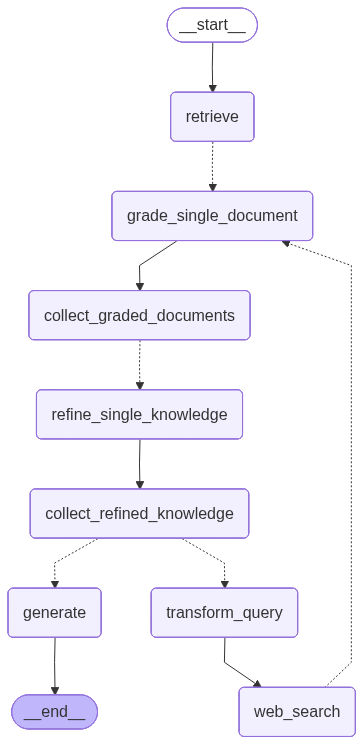

In [22]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 워크플로우 그래프 초기화
builder = StateGraph(GraphState)

# 노드 정의
builder.add_node("retrieve", retrieve)  # 문서 검색
builder.add_node("web_search", web_search)  # 웹 검색

# Map-Reduce를 위한 노드들
builder.add_node("grade_single_document", grade_single_document)  # 개별 문서 평가 (Map)
builder.add_node("collect_graded_documents", collect_graded_documents)  # 문서 평가 결과 수집 (Reduce)
builder.add_node("refine_single_knowledge", refine_single_knowledge)  # 개별 지식 정제 (Map)
builder.add_node("collect_refined_knowledge", collect_refined_knowledge)  # 지식 정제 결과 수집 (Reduce)

# 기타 노드들
builder.add_node("generate", generate)  # 답변 생성
builder.add_node("transform_query", transform_query)  # 질문 개선

# 경로 정의
builder.add_edge(START, "retrieve")

# 문서 평가를 위한 Map-Reduce 패턴
# conditional_edges에서 Send를 반환하는 함수를 전달
builder.add_conditional_edges(
    "retrieve",
    distribute_documents_for_grading,  # Map: 각 문서를 개별 평가로 분산
    ["grade_single_document"]  # Send가 보낼 수 있는 노드 목록
)
builder.add_edge("grade_single_document", "collect_graded_documents")  # Reduce: 평가 결과 수집

# 지식 정제를 위한 Map-Reduce 패턴
builder.add_conditional_edges(
    "collect_graded_documents",
    distribute_documents_for_refining,  # Map: 각 문서를 개별 정제로 분산
    ["refine_single_knowledge"]  # Send가 보낼 수 있는 노드 목록
)
builder.add_edge("refine_single_knowledge", "collect_refined_knowledge")  # Reduce: 정제 결과 수집

# 조건부 엣지 추가: 문서 평가 후 결정
builder.add_conditional_edges(
    "collect_refined_knowledge",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)

# 웹 검색 후 다시 문서 평가로 진입
builder.add_conditional_edges(
    "web_search",
    distribute_documents_for_grading,  # 웹 검색 후에도 Map-Reduce 패턴 적용
    ["grade_single_document"]
)

# 추가 경로
builder.add_edge("transform_query", "web_search")
builder.add_edge("generate", END)

# 그래프 컴파일
graph = builder.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

`(5) 그래프 실행`

In [23]:
# 첫 번째 예시
inputs = {"question": "스테이크 메뉴의 가격은 얼마인가요?"}
final_state = graph.invoke(inputs)

2025-11-06 19:42:13,337 - root - INFO - --- 문서 검색 ---
2025-11-06 19:42:13,624 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:13,627 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.3
2025-11-06 19:42:13,627 - __main__ - INFO - 🔍 1차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:13,888 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:13,891 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.1
2025-11-06 19:42:13,892 - __main__ - INFO - 🔍 2차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:14,276 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:14,279 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.0
2025-11-06 19:42:14,279 - __main__ - INF

In [24]:
# 최종 답변
print(final_state.get("generation", "답변 생성 실패"))

답변 생성 실패


In [25]:
# 두 번째 예시
inputs = {"question": "스테이크에 어울리는 와인을 추천해주세요."}
final_state = graph.invoke(inputs)

2025-11-06 19:42:14,296 - root - INFO - --- 문서 검색 ---
2025-11-06 19:42:14,601 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:14,604 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.3
2025-11-06 19:42:14,604 - __main__ - INFO - 🔍 1차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:15,180 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:15,183 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.1
2025-11-06 19:42:15,184 - __main__ - INFO - 🔍 2차 검색 모드: 0개의 문서 검색
2025-11-06 19:42:15,452 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:42:15,455 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.0
2025-11-06 19:42:15,455 - __main__ - INF

In [26]:
# 최종 답변
print(final_state.get("generation", "답변 생성 실패"))

답변 생성 실패


---
### **[실습]**

- State, Node, Edge를 직접 구성하여, Corrective RAG 시스템을 구현합니다. 
- 그래프 구현을 통해 RAG 품질을 개선하는 과정을 이해합니다.
- 데이터:
    - data/housing_leasing_law.pdf
    - data/labor_law.pdf
    - data/personal_info_law.pdf
    

📚 법률 문서 로딩 중...
✅ data/housing_leasing_law.pdf 로딩 완료: 10개 페이지
✅ data/labor_law.pdf 로딩 완료: 20개 페이지
✅ data/personal_info_law.pdf 로딩 완료: 41개 페이지
📄 총 218개의 청크로 분할 완료


2025-11-06 19:51:46,722 - chromadb.telemetry.product.posthog - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
2025-11-06 19:51:50,475 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


✅ 벡터 저장소 생성 완료


🔧 법률 CRAG 그래프 구축 중...
✅ 그래프 구축 완료



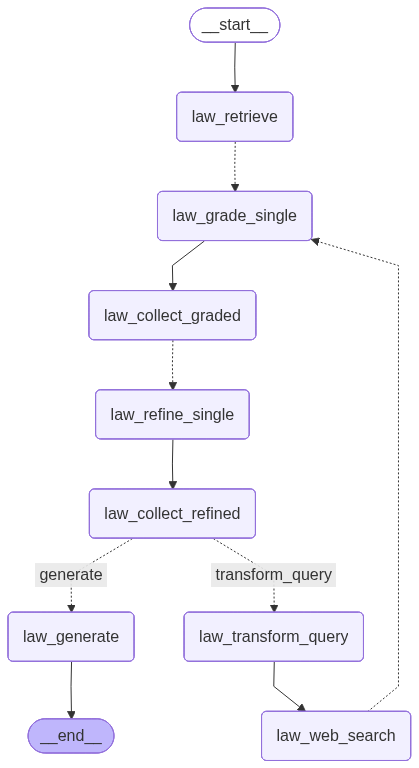

2025-11-06 19:51:53,689 - root - INFO - --- 법률 문서 검색 ---



🧪 법률 CRAG 시스템 테스트


📋 테스트 1: 전세 계약 시 임차인이 보호받을 수 있는 권리는 무엇인가요?


2025-11-06 19:51:54,038 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:51:54,143 - langchain_core.vectorstores.base - WARNING - No relevant docs were retrieved using the relevance score threshold 0.4
2025-11-06 19:51:54,145 - __main__ - INFO - 🔍 1차 검색: 0개 문서
2025-11-06 19:51:54,433 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:51:54,436 - __main__ - INFO - 🔍 2차 검색: 5개 문서
2025-11-06 19:51:54,437 - root - INFO - 검색된 문서: 5개
2025-11-06 19:51:54,439 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:51:54,448 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:51:54,450 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:51:54,472 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:51:54,473 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:51:55,684 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-06 19:51:55,687 - httpx - INFO - HTTP Reques


💡 최종 답변:
전세 계약 시 임차인이 보호받을 수 있는 권리는 다음과 같습니다.

1. 임대차계약 체결 시 임대인으로부터 확정일자 부여일, 차임 및 보증금 등의 정보를 제공받고, 납세증명서 제출 또는 열람 동의를 받을 권리  
2. 임대인이 갱신거절 통지를 임대차기간 종료 6개월 전부터 2개월 전까지 하지 않으면, 전 임대차와 동일한 조건으로 계약이 자동 갱신되는 권리  
3. 계약갱신요구권을 1회 행사할 수 있으며, 갱신되는 임대차의 존속기간은 2년으로 인정받는 권리  
4. 갱신되는 임대차는 전 임대차와 동일한 조건으로 계약되나, 차임과 보증금은 일정 범위 내에서 증감될 수 있음  
5. 임대인이 정당한 사유 없이 갱신거절 후 제3자에게 임대주택을 임대한 경우, 임차인은 손해배상을 청구할 수 있으며, 손해배상액은 월차임 3개월분 이상임  
6. 임차인이 제7조에 따른 증액비율을 초과하여 차임 또는 보증금을 지급한 경우 초과금 반환을 청구할 수 있는 권리

이 외에 임대인의 직계존속·직계비속이 실제 거주하려는 경우에만 갱신거절이 가능하므로, 임차인의 거주권이 보호됩니다.

📊 생성 횟수: 1
📚 사용된 지식: 4개
------------------------------------------------------------

📋 테스트 2: 근로자의 연차 휴가 사용 권리에 대해 설명해주세요.


2025-11-06 19:52:04,127 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:52:04,131 - __main__ - INFO - 🔍 1차 검색: 3개 문서
2025-11-06 19:52:04,132 - root - INFO - 검색된 문서: 3개
2025-11-06 19:52:04,133 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:52:04,135 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:52:04,136 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:52:04,864 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-06 19:52:04,878 - root - INFO - ✅ 문서 관련성: 높음
2025-11-06 19:52:05,019 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-06 19:52:05,029 - root - INFO - ❌ 문서 관련성: 낮음
2025-11-06 19:52:05,469 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-06 19:52:05,486 - root - INFO - ✅ 문서 관련성: 높음
2025-11-06 19:52:05,488 - root - INFO - --- 평가 결과 수집 ---
2025-11-06 19:52:05,489 -


💡 최종 답변:
근로자는 청구한 시기에 연차 휴가를 사용할 권리가 있으며, 사용 기간에 대해 통상임금 또는 평균임금을 지급받아야 합니다. 다만, 사업 운영에 막대한 지장이 있는 경우에는 휴가 시기를 변경할 수 있습니다. 또한, 사용자는 최초 1년 근로기간 종료 3개월 전을 기준으로 10일 이내에 근로자별 미사용 휴가 일수를 알려주고, 근로자가 사용 시기를 정하여 서면으로 통보하도록 촉구해야 합니다.

📊 생성 횟수: 1
📚 사용된 지식: 2개
------------------------------------------------------------

📋 테스트 3: 개인정보 수집 시 동의를 받아야 하는 경우는 언제인가요?


2025-11-06 19:52:10,724 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-11-06 19:52:10,728 - __main__ - INFO - 🔍 1차 검색: 2개 문서
2025-11-06 19:52:10,729 - root - INFO - 검색된 문서: 2개
2025-11-06 19:52:10,731 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:52:10,733 - root - INFO - --- 개별 문서 평가 ---
2025-11-06 19:52:11,182 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-06 19:52:11,190 - root - INFO - ✅ 문서 관련성: 높음
2025-11-06 19:52:11,191 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-06 19:52:11,200 - root - INFO - ✅ 문서 관련성: 높음
2025-11-06 19:52:11,201 - root - INFO - --- 평가 결과 수집 ---
2025-11-06 19:52:11,201 - root - INFO - 수집 완료: 2개 문서
2025-11-06 19:52:11,202 - root - INFO - --- 개별 지식 정제 ---
2025-11-06 19:52:11,203 - root - INFO - --- 개별 지식 정제 ---
2025-11-06 19:52:12,660 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/cha


💡 최종 답변:
개인정보 수집 시 동의는 정보주체가 명확히 인지할 수 있도록 각각의 동의 사항을 구분하여 받아야 하며, 수집ㆍ이용 목적, 수집하려는 개인정보 항목, 보유 및 이용 기간, 동의 거부 권리 및 불이익 내용을 알릴 때 필요합니다.

📊 생성 횟수: 1
📚 사용된 지식: 2개
------------------------------------------------------------

✅ 모든 테스트 완료!


In [28]:
# ============================================================
# [실습] 법률 문서 기반 Corrective RAG 시스템 구현
# ============================================================

# 1. PDF 문서 로딩 및 벡터 저장소 생성
# ------------------------------------------------------------
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

print("📚 법률 문서 로딩 중...")

# PDF 파일 경로
pdf_files = [
    "data/housing_leasing_law.pdf",
    "data/labor_law.pdf", 
    "data/personal_info_law.pdf"
]

# 문서 로딩
all_documents = []
for pdf_path in pdf_files:
    loader = PyPDFLoader(pdf_path)
    documents = loader.load()
    all_documents.extend(documents)
    print(f"✅ {pdf_path} 로딩 완료: {len(documents)}개 페이지")

# 텍스트 분할
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separators=["\n\n", "\n", ".", " ", ""]
)
split_docs = text_splitter.split_documents(all_documents)
print(f"📄 총 {len(split_docs)}개의 청크로 분할 완료")

# 벡터 저장소 생성
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
law_vector_db = Chroma.from_documents(
    documents=split_docs,
    embedding=embeddings,
    collection_name="law_documents",
    persist_directory="./chroma_law_db"
)
print("✅ 벡터 저장소 생성 완료\n")


# 2. 법률 문서용 적응형 벡터 저장소
# ------------------------------------------------------------
class LawVectorStore:
    """법률 문서 검색을 위한 적응형 벡터 저장소"""
    
    def __init__(self, vector_db):
        self.vector_db = vector_db
        self.search_configs = {
            "initial": {"k": 3, "score_threshold": 0.4},
            "expanded": {"k": 5, "score_threshold": 0.2},
            "exhaustive": {"k": 8, "score_threshold": 0.0}
        }
    
    def multi_stage_search(self, query: str):
        """다단계 검색 전략"""
        # 1차: 정밀 검색
        initial = self.vector_db.as_retriever(
            search_type="similarity_score_threshold",
            search_kwargs=self.search_configs["initial"]
        ).invoke(query)
        
        logger.info(f"🔍 1차 검색: {len(initial)}개 문서")
        
        if len(initial) < 1:
            # 2차: 확장 검색
            expanded = self.vector_db.as_retriever(
                search_type="similarity_score_threshold",
                search_kwargs=self.search_configs["expanded"]
            ).invoke(query)
            
            logger.info(f"🔍 2차 검색: {len(expanded)}개 문서")
            
            if len(expanded) < 1:
                # 3차: 포괄 검색
                exhaustive = self.vector_db.as_retriever(
                    search_type="similarity_score_threshold",
                    search_kwargs=self.search_configs["exhaustive"]
                ).invoke(query)
                
                logger.info(f"🔍 3차 검색: {len(exhaustive)}개 문서")
                return exhaustive
            
            return expanded
        
        return initial

# 법률 문서용 벡터 저장소 초기화
law_retriever = LawVectorStore(law_vector_db)


# 3. State 정의
# ------------------------------------------------------------
class LawGraphState(TypedDict):
    """법률 문서 CRAG 그래프 상태"""
    question: str
    generation: str
    retrieved_documents: List[Tuple[Document, str]]
    knowledge_strips: List[Tuple[Document, str]]
    num_generations: int
    graded_documents: Annotated[list, operator.add]
    refined_knowledge: Annotated[list, operator.add]


# 4. Node 구성
# ------------------------------------------------------------

# (1) 문서 검색
def law_retrieve(state: LawGraphState) -> LawGraphState:
    """법률 문서 검색"""
    logging.info("--- 법률 문서 검색 ---")
    question = state["question"]
    
    retrieved_documents = law_retriever.multi_stage_search(question)
    retrieved_documents = [(doc, "ambiguous") for doc in retrieved_documents]
    
    logging.info(f"검색된 문서: {len(retrieved_documents)}개")
    return {"retrieved_documents": retrieved_documents}


# (2) 웹 검색
def law_web_search(state: LawGraphState) -> LawGraphState:
    """법률 관련 웹 검색"""
    logging.info("--- 법률 관련 웹 검색 ---")
    question = state["question"]
    
    # 법률 관련 검색어 강화
    enhanced_query = f"대한민국 법률 {question}"
    search_results = search_tool.invoke(enhanced_query)['results']
    
    retrieved_documents = [(Document(page_content=str(result)), "ambiguous") 
                          for result in search_results[:3]]
    
    logging.info(f"웹 검색 결과: {len(retrieved_documents)}개")
    return {"retrieved_documents": retrieved_documents}


# (3) 문서 평가 분배
def law_distribute_grading(state: LawGraphState):
    """문서 평가를 위한 분배"""
    retrieved_documents = state.get("retrieved_documents", [])
    question = state["question"]
    
    return [
        Send("law_grade_single", {
            "question": question,
            "document": doc,
            "grade": grade
        })
        for doc, grade in retrieved_documents
    ]


# (4) 개별 문서 평가
def law_grade_single(state: Dict) -> Dict:
    """개별 법률 문서 평가"""
    logging.info("--- 개별 문서 평가 ---")
    question = state["question"]
    document = state["document"]
    
    score = retrieval_grader.invoke({
        "question": question, 
        "document": document.page_content
    })
    grade = score.relevance_score.lower()
    
    if grade == "correct":
        logging.info("✅ 문서 관련성: 높음")
        return {"graded_documents": [(document, "correct")]}
    elif grade == "incorrect":
        logging.info("❌ 문서 관련성: 낮음")
        return {"graded_documents": [(document, "incorrect")]}
    else:
        logging.info("⚠️ 문서 관련성: 모호함")
        return {"graded_documents": [(document, "ambiguous")]}


# (5) 평가된 문서 수집
def law_collect_graded(state: LawGraphState) -> LawGraphState:
    """평가된 문서 수집"""
    logging.info("--- 평가 결과 수집 ---")
    graded_documents = state.get("graded_documents", [])
    
    # 리스트 평면화
    flattened_docs = []
    for item in graded_documents:
        if isinstance(item, list):
            flattened_docs.extend([i for i in item if i])
        elif item:
            flattened_docs.append(item)
    
    logging.info(f"수집 완료: {len(flattened_docs)}개 문서")
    return {"retrieved_documents": flattened_docs, "graded_documents": []}


# (6) 지식 정제 분배
def law_distribute_refining(state: LawGraphState):
    """지식 정제를 위한 분배"""
    graded_documents = state.get("graded_documents", [])
    question = state["question"]
    
    # 평면화
    flattened_docs = []
    for item in graded_documents:
        if isinstance(item, list):
            flattened_docs.extend(item)
        else:
            flattened_docs.append(item)
    
    return [
        Send("law_refine_single", {
            "question": question,
            "document": doc,
            "grade": grade
        })
        for doc, grade in flattened_docs
    ]


# (7) 개별 지식 정제
def law_refine_single(state: Dict) -> Dict:
    """개별 법률 지식 정제"""
    logging.info("--- 개별 지식 정제 ---")
    question = state["question"]
    document = state["document"]
    grade = state.get("grade", "")
    
    # 관련성 없는 문서 제외
    if grade == "incorrect":
        return {"refined_knowledge": []}
    
    refined = knowledge_refiner.invoke({
        "question": question,
        "document": document.page_content
    })
    
    knowledge = refined.knowledge_strip
    binary_score = refined.binary_score
    
    if binary_score == "yes":
        logging.info("✅ 지식 추가")
        return {"refined_knowledge": [(Document(page_content=knowledge), "correct")]}
    else:
        logging.info("❌ 지식 제외")
        return {"refined_knowledge": []}


# (8) 정제된 지식 수집
def law_collect_refined(state: LawGraphState) -> LawGraphState:
    """정제된 지식 수집"""
    logging.info("--- 정제된 지식 수집 ---")
    refined_knowledge = state.get("refined_knowledge", [])
    
    # 평면화 및 빈 항목 제거
    knowledge_strips = []
    for item in refined_knowledge:
        if isinstance(item, list):
            knowledge_strips.extend([i for i in item if i])
        elif item:
            knowledge_strips.append(item)
    
    logging.info(f"정제 완료: {len(knowledge_strips)}개 지식")
    return {"knowledge_strips": knowledge_strips, "refined_knowledge": []}


# (9) 답변 생성
def law_generate(state: LawGraphState) -> LawGraphState:
    """법률 답변 생성"""
    logging.info("--- 답변 생성 ---")
    num_generations = state.get("num_generations", 0)
    question = state["question"]
    knowledge_strips = state.get("knowledge_strips", [])
    
    if not knowledge_strips:
        generation = "죄송합니다. 해당 질문에 대한 법률 정보를 찾을 수 없습니다."
    else:
        doc_texts = [doc for doc, _ in knowledge_strips]
        generation = generator_answer(question, docs=doc_texts)
    
    num_generations += 1
    return {"generation": generation, "num_generations": num_generations}


# (10) 질문 변환
def law_transform_query(state: LawGraphState) -> LawGraphState:
    """법률 질문 재작성"""
    logging.info("--- 질문 재작성 ---")
    question = state["question"]
    
    # 법률 도메인에 최적화된 질문 재작성
    rewritten = rewrite_question(question)
    logging.info(f"원본: {question}")
    logging.info(f"재작성: {rewritten}")
    
    return {"question": rewritten}


# 5. Edge 정의
# ------------------------------------------------------------
def law_decide_to_generate(state: LawGraphState) -> str:
    """답변 생성 여부 결정"""
    logging.info("--- 생성 여부 결정 ---")
    knowledge_strips = state.get("knowledge_strips", [])
    num_generations = state.get("num_generations", 0)
    
    # 최대 생성 횟수 제한
    if num_generations >= 3:
        logging.info("⚠️ 최대 생성 횟수 도달")
        return "generate"
    
    if not knowledge_strips:
        logging.info("🔄 지식 부족 -> 질문 재작성")
        return "transform_query"
    else:
        logging.info("✅ 답변 생성 가능")
        return "generate"


# 6. 그래프 구축
# ------------------------------------------------------------
from langgraph.graph import StateGraph, START, END

print("\n🔧 법률 CRAG 그래프 구축 중...")

# 그래프 초기화
law_builder = StateGraph(LawGraphState)

# 노드 추가
law_builder.add_node("law_retrieve", law_retrieve)
law_builder.add_node("law_web_search", law_web_search)
law_builder.add_node("law_grade_single", law_grade_single)
law_builder.add_node("law_collect_graded", law_collect_graded)
law_builder.add_node("law_refine_single", law_refine_single)
law_builder.add_node("law_collect_refined", law_collect_refined)
law_builder.add_node("law_generate", law_generate)
law_builder.add_node("law_transform_query", law_transform_query)

# 경로 정의
law_builder.add_edge(START, "law_retrieve")

# Map-Reduce: 문서 평가
law_builder.add_conditional_edges(
    "law_retrieve",
    law_distribute_grading,
    ["law_grade_single"]
)
law_builder.add_edge("law_grade_single", "law_collect_graded")

# Map-Reduce: 지식 정제
law_builder.add_conditional_edges(
    "law_collect_graded",
    law_distribute_refining,
    ["law_refine_single"]
)
law_builder.add_edge("law_refine_single", "law_collect_refined")

# 조건부 분기: 답변 생성 또는 질문 재작성
law_builder.add_conditional_edges(
    "law_collect_refined",
    law_decide_to_generate,
    {
        "transform_query": "law_transform_query",
        "generate": "law_generate"
    }
)

# 웹 검색 후 평가
law_builder.add_conditional_edges(
    "law_web_search",
    law_distribute_grading,
    ["law_grade_single"]
)

# 질문 재작성 후 웹 검색
law_builder.add_edge("law_transform_query", "law_web_search")

# 답변 생성 후 종료
law_builder.add_edge("law_generate", END)

# 그래프 컴파일
law_graph = law_builder.compile()

print("✅ 그래프 구축 완료\n")

# 그래프 시각화
try:
    from IPython.display import Image, display
    display(Image(law_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"⚠️ 그래프 시각화 실패: {e}")


# 7. 테스트 실행
# ------------------------------------------------------------
print("\n" + "="*60)
print("🧪 법률 CRAG 시스템 테스트")
print("="*60 + "\n")

# 테스트 질문 1: 주택임대차보호법
test_questions = [
    "전세 계약 시 임차인이 보호받을 수 있는 권리는 무엇인가요?",
    "근로자의 연차 휴가 사용 권리에 대해 설명해주세요.",
    "개인정보 수집 시 동의를 받아야 하는 경우는 언제인가요?"
]

for i, question in enumerate(test_questions, 1):
    print(f"\n{'='*60}")
    print(f"📋 테스트 {i}: {question}")
    print('='*60)
    
    # 그래프 실행
    result = law_graph.invoke({"question": question})
    
    # 결과 출력
    print(f"\n💡 최종 답변:\n{result.get('generation', '답변 없음')}")
    print(f"\n📊 생성 횟수: {result.get('num_generations', 0)}")
    print(f"📚 사용된 지식: {len(result.get('knowledge_strips', []))}개")
    print('-'*60)

print("\n✅ 모든 테스트 완료!")